# Clasificación de Mensajes de Odio (Hate Speech Detection)
**Autor:** Gregory Harutyuyan Gevorgyan | **Dominio:** NLP / Clasificación Binaria

**Resumen:**
Este notebook orquesta el pipeline de modelado para la detección de mesajes de odio. Las fases incluyen un Análisis Exploratorio (EDA), la evaluación comparativa entre modelos lineales (Regresión Logística) y topológicos (LightGBM), la optimización del modelo seleccionado y la auditoría final de explicabilidad mediante valores SHAP.

*Para el detalle de las variables, consultar `DATA_DICTIONARY.md`.*

<hr>

## **1. ANÁLISIS EXPLORATORIO (EDA) Y FEATURE ENGINEERING**

In [1]:
# Carga automática de módulos externos (autoreload)
%load_ext autoreload
%autoreload 2

### **1.1. Preprocesado del dataset**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

ROOT_DIR = os.path.abspath('..')
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

In [3]:
from src.data_prep import load_and_audit_data

FILEPATH = "../data/raw/dataset_hate_speech.csv"  # Definimos la ruta de nuestro archivo CSV
df, info_df = load_and_audit_data(FILEPATH)

# Mostramos el resultado de la auditoría
display(info_df)

✅ Shape inicial: 10000 filas | 22 columnas.
⚠️ ALERTA: 539 filas duplicadas detectadas. Esto sesgará la validación.


,Dtype,Nulos_NaN,Nulos_Vacios,Unicos
A,int64,0,0,17
B,int64,0,0,189
C,int64,0,0,66
D,int64,0,0,7
E,int64,0,0,7
comentario,object,0,0,9461
label,int8,0,0,2
A_t,float64,0,0,17
B_t,float64,0,0,189
C_t,float64,0,0,66


A pesar de que las especificaciones previas del dataset indicaban que los duplicados habían sido tratados, la auditoría revela la existencia de 539 registros duplicados (aprox. 5.4% del volumen total).

Mantener estos registros introduce un alto riesgo de Data Leakage en la fase de modelado. 

**Decisión**: Se procederá a la eliminación de estos registros antes de iniciar cualquier análisis exploratorio.

In [4]:
# Eliminamos los duplicados
df = df.drop_duplicates().reset_index(drop=True)

print(f"✅ Limpieza ejecutada. Nuevo shape del dataset: {df.shape[0]} filas | {df.shape[1]} columnas.")

✅ Limpieza ejecutada. Nuevo shape del dataset: 9461 filas | 22 columnas.


In [5]:
pd.set_option('display.max_columns', None)
df.head(-5)

,A,B,C,D,E,comentario,label,A_t,B_t,C_t,D_t,E_t,Valor_1,Valor_2,Valor_3,Valor_4,Valor_5,Valor_6,Valor_7,Valor_8,Valor_9,Valor_10
0,2,64,30,0,2,"pandemia,originado,covid,cierto,incidencia,aba...",0,1.851102,2.759647,7.145831,-0.416577,0.440638,5.108388,13.227660,-0.771127,0.815665,19.719970,-1.149606,1.216004,-2.976790,3.148722,-0.183560
1,4,70,21,0,0,"ser,mes,larga,espera,llegar,momento,siempre,pr...",0,3.990202,3.054765,4.877255,-0.416577,-0.531099,12.189130,19.461233,-1.662227,-2.119191,14.898871,-1.272546,-1.622382,-2.031754,-2.590305,0.221244
2,4,88,50,0,0,"cartagena,san,sebastiar,fuengirola,irun,orense...",0,3.990202,3.940120,12.187108,-0.416577,-0.531099,15.721875,48.629021,-1.662227,-2.119191,48.018675,-1.641365,-2.092593,-5.076872,-6.472559,0.221244
3,3,38,21,0,0,"pleno,dia,verano,calor,plan,mas,apetecibl,disf...",0,2.920652,1.480801,4.877255,-0.416577,-0.531099,4.324903,14.244765,-1.216677,-1.551155,7.222244,-0.616868,-0.786452,-2.031754,-2.590305,0.221244
4,0,59,17,0,0,"pasado,junio,celebro,dia,luchar,frente,leishma...",0,-0.287998,2.513715,3.869000,-0.416577,-0.531099,-0.723945,-1.114264,0.119973,0.152955,9.725563,-1.047156,-1.335031,-1.611737,-2.054821,0.221244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9451,1,1,2,0,1,"serio,hablar,bori,vulgaridad,arrogante,penar,g...",1,0.781552,-0.339096,0.088042,-0.416577,-0.045231,-0.265021,0.068809,-0.325577,-0.035350,-0.029855,0.141260,0.015337,-0.036676,-0.003982,0.018842
9452,0,2,1,1,6,"enserio,@borisizaguirre,escribi,semejante,burr...",1,-0.287998,-0.289909,-0.164022,1.500246,2.384111,0.083493,0.047238,-0.432068,-0.686619,0.047552,-0.434935,-0.691176,-0.246074,-0.391047,3.576752
9453,0,0,1,0,6,"envidioso,",1,-0.287998,-0.388282,-0.164022,-0.416577,2.384111,0.111824,0.047238,0.119973,-0.686619,0.063687,0.161750,-0.925708,0.068328,-0.391047,-0.993166
9454,0,2,2,0,6,"titulo,propio,envidioso,resentido,social,",1,-0.287998,-0.289909,0.088042,-0.416577,2.384111,0.083493,-0.025356,0.119973,-0.686619,-0.025524,0.120770,-0.691176,-0.036676,0.209901,-0.993166


### **1.2. Aclaraciones de algunas variables**

#### I. Variable objetivo: 'label'

Investigamos acerca del etiquetado de la variable obetivo...

In [6]:
import pandas as pd

# Fijamos una semilla para reproducibilidad
SEED = 42

print("--------------------------")
print("AUDITORÍA DE ETIQUETAS ")
print("--------------------------")


# Extraemos 5 muestras aleatorias de la Clase 1
print("\n--> MUESTRAS DE LA CLASE [ 1 ]:")
for texto in df[df['label'] == 1]['comentario'].sample(5, random_state=SEED):
    print(f"- {texto}")

print("\n--------------------------------------------------\n")

# Extraemos 5 muestras aleatorias de la Clase 0
print("--> MUESTRAS DE LA CLASE [ 0 ]:")
for texto in df[df['label'] == 0]['comentario'].sample(5, random_state=SEED):
    print(f"- {texto}")

--------------------------
AUDITORÍA DE ETIQUETAS 
--------------------------

--> MUESTRAS DE LA CLASE [ 1 ]:
- alimentar,odio,suspicazmente,bastante,energumeno,esperar,buscar,culpable,periodismo,manipulador,mediatico,odio,
- imbecil,creer,mentira,
- pues,ver,cortar,polla,hincar,sacacorchos,ojo,
- menudo,payaso,
- pedazo,golfo,poco,

--------------------------------------------------

--> MUESTRAS DE LA CLASE [ 0 ]:
- informado,ultimo,hora,hoy,esencial,conocer,mundo,rodear,demasiado,tiempo,abc,poner,disposicion,lector,desear,mejor,resumen,sabado,julio,aqui,mismo,espectacular,hallazgo,sarcofago,epocar,visigoda,posiblemente,siglo,necropolis,villa,romano,villarico,mulo,murcia,asombrado,equipo,investigacion,universidad,murcia,liderado,catedratico,historia,antiguo,rafael,gonzalez,fernandez,habio,comenzado,lunes,campaña,centrar,ultima,tres,tumba,quedar,excavar,dia,siguiente,llevar,sorpresa,campana,repicar,despedir,muerto,espantar,tormenta,,llevar,apreciar,sonido,pequeño,atraen,beber,produci

**Confirmación**: La 'clase 0' corresponde con los comenarios SIN ODIO y la 'clase 1' corresponde con los comentarios CON ODIO.

#### II. Variables predictoras


Visualizamos las categorías de la variable 'E':

In [7]:
print(f"La variable 'E' contiene estas etiquetas: {df["E"].unique()}")

La variable 'E' contiene estas etiquetas: [2 0 1 6 3 4 5]


Comprobamos cómo se han generado las variables 'Valor_i':

In [8]:
import itertools

COLS_t = ["A_t","B_t","C_t","D_t","E_t"]

row = df.loc[0]

for i, (c1,c2) in enumerate(itertools.combinations(COLS_t, 2), 1):
    product = row[c1]*row[c2]
    real = row[f"Valor_{i}"]

    check = np.isclose(product, real)

    print(f"Valor_{i:02d} --> {c1} * {c2} = {product:.5f} | real={real:.5f} | match: {check}")

Valor_01 --> A_t * B_t = 5.10839 | real=5.10839 | match: True
Valor_02 --> A_t * C_t = 13.22766 | real=13.22766 | match: True
Valor_03 --> A_t * D_t = -0.77113 | real=-0.77113 | match: True
Valor_04 --> A_t * E_t = 0.81567 | real=0.81567 | match: True
Valor_05 --> B_t * C_t = 19.71997 | real=19.71997 | match: True
Valor_06 --> B_t * D_t = -1.14961 | real=-1.14961 | match: True
Valor_07 --> B_t * E_t = 1.21600 | real=1.21600 | match: True
Valor_08 --> C_t * D_t = -2.97679 | real=-2.97679 | match: True
Valor_09 --> C_t * E_t = 3.14872 | real=3.14872 | match: True
Valor_10 --> D_t * E_t = -0.18356 | real=-0.18356 | match: True


- La variable E representa el índice de sentimiento según la librería 'pysentimiento', codificada como: 
{
  0: 'anger',
  1: 'disgust',
  2: 'fear',
  3: 'joy',
  4: 'sadness',
  5: 'surprise',
  6: 'others'
}.
  -  **Posible error de diseño del dataset**: la variable E (Sentimiento) es de naturaleza categórica nominal (pendiente de análisis para comprobar si existe relación de ordinalidad). Su estandarización a E_t y posterior multiplicación con variables continuas carece de sentido matemático. Los términos de interacción generados a partir de E_t probablemente introducirán ruido en el modelo y son candidatos a ser eliminados durante la fase previa al modelado

- Las variables Valor_1 a Valor_10 corresponden a los términos del producto cruzado entre cada par de características estandarizadas. Respecto a su utilidad cabe destacar:

  - Con estas variables se dota a los algoritmos lineales de la capacidad de trazar límites de **separación no lineales**. Sin embargo, si se opta por modelos de árboles de decisión, estas variables introducen redundancia, dado que dichos algoritmos modelan las iteracciones de forma nativa.

  - **Riesgo de Multicolinealidad**: La creación de variables producto induce alta colinealidad con sus variables de origen, lo que exigirá regularización (Lasso/Ridge) para estabilizar la varianza de los pesos antes de aplicar métodos lineales.

### **1.3. Análisis de la variable objetivo**

In [9]:
TARGET = 'label'

--- Distribución de Clases ---
Clase 0: 52.53%
Clase 1: 47.47%
------------------------------


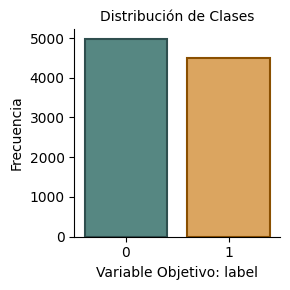

In [10]:
from src.plots import plot_distribucion_target

# Ejecutamos el análisis de la variable dependiente
plot_distribucion_target(df, target_col=TARGET)

**Métricas de Evaluación:** La ausencia de un desbalanceo entre las clases nos permite utilizar **Accuracy** y **ROC‑AUC** como métricas fiables para ajustar los modelos. Aun así, seguiremos revisando el **F1‑Score Macro** para asegurarnos de que tanto la *precisión* como el *recall* se mantienen sólidos en ambas clases y que el modelo funciona bien en todos los casos.


--- Auditoría Avanzada del Target: 'label' ---
🎯 Baseline (Zero Rule): 52.53%
   (Cualquier modelo de ML debe superar este Accuracy prediciendo la clase 0)
✅ Integridad Lógica: 0 contradicciones detectadas entre características y etiquetas.
--------------------------------------------------


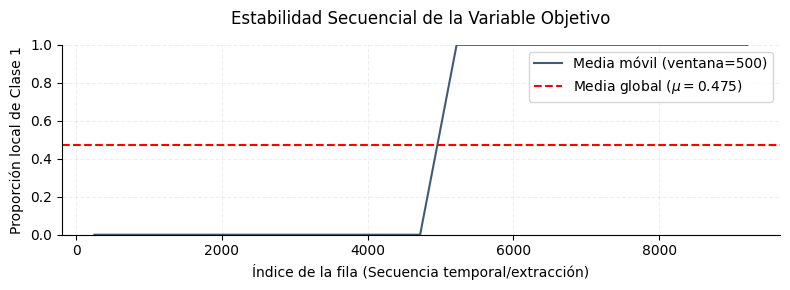

In [11]:
from src.data_prep import auditar_calidad_target
from src.plots import plot_estabilidad_secuencial

# 1. Auditoría matemática y Baseline
baseline, contradicciones = auditar_calidad_target(df, target_col=TARGET)

# 2. Análisis de Estacionariedad
# Usamos una ventana de 500 muestras para suavizar el ruido
plot_estabilidad_secuencial(df, target_col=TARGET, window=500)

**1. Baseline (Zero Rule)**
- El baseline calculado para este dataset es **52.53%**.  
- Esto representa el rendimiento mínimo que debe superar cualquier modelo para demostrar que está aprendiendo patrones reales y no simplemente replicando la clase mayoritaria.


**2. Bayes Error (Contradicciones en el etiquetado)**
- Se han encontrado **0 contradicciones** (vectores de características idénticos con etiquetas distintas).  
- Esto sugiere que, dentro del dataset observado, **no hay ruido intrínseco detectable en las etiquetas**, por lo que el límite teórico de rendimiento podría ser muy alto.


**3. Distribución secuencial de la variable objetivo**

Al analizar la proporción de la clase a lo largo del índice del dataset, se observa:

- Aproximadamente el primer 50% de las filas pertenece a la clase 0.
- El 50% restante pertenece a la clase 1.

**Implicación:** Si se realizara un `train_test_split` sin barajar los datos, el modelo:

- Entrenaría casi exclusivamente con ejemplos de la clase 0.
- Evaluaría casi exclusivamente con ejemplos de la clase 1.

**Decisión:** Se aplica un *shuffle aleatorio* al dataset para garantizar que ambas clases queden mezcladas antes de cualquier partición.


In [12]:
# 1. Permutación aleatoria global de la matriz de datos
# frac=1: Selecciona el 100% de las filas (no perdemos datos, solo los reordenamos)
# random_state=42: Fija la semilla para garantizar la reproducibilidad
df = df.sample(frac=1, random_state=42)

# 2. Reconstrucción del índice
# Es necesario resetear el índice y eliminar el antiguo para que las transformaciones
# posteriores (como concatenaciones o joins) no hereden la estructura anterior.
df = df.reset_index(drop=True)

print(f"✅ Dataset barajado y saneado. Shape actual: {df.shape[0]} filas | {df.shape[1]} columnas.")

✅ Dataset barajado y saneado. Shape actual: 9461 filas | 22 columnas.


--- Auditoría Avanzada del Target: 'label' ---
🎯 Baseline (Zero Rule): 52.53%
   (Cualquier modelo de ML debe superar este Accuracy prediciendo la clase 0)
✅ Integridad Lógica: 0 contradicciones detectadas entre características y etiquetas.
--------------------------------------------------


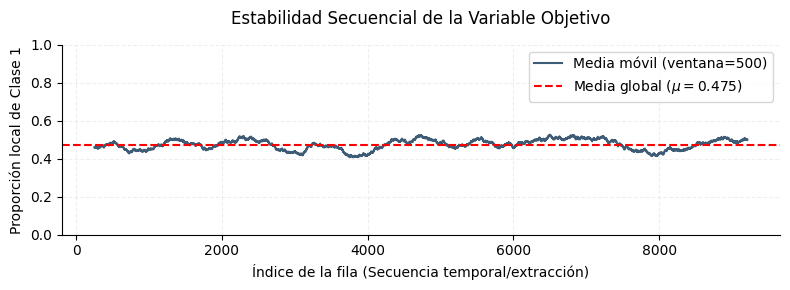

In [13]:
from src.data_prep import auditar_calidad_target
from src.plots import plot_estabilidad_secuencial

TARGET = "label"

# 1. Auditoría matemática y Baseline
baseline, contradicciones = auditar_calidad_target(df, target_col=TARGET)

# 2. Análisis de Estacionariedad
# Usamos una ventana de 500 muestras para suavizar el ruido
plot_estabilidad_secuencial(df, target_col=TARGET, window=500)

### **1.4. Análisis exploratorio del espacio de características**

#### I. Variables base numéricas

------ AUDITORÍA DE VARIABLES BASE NUMÉRICAS ------

Topología Univariante


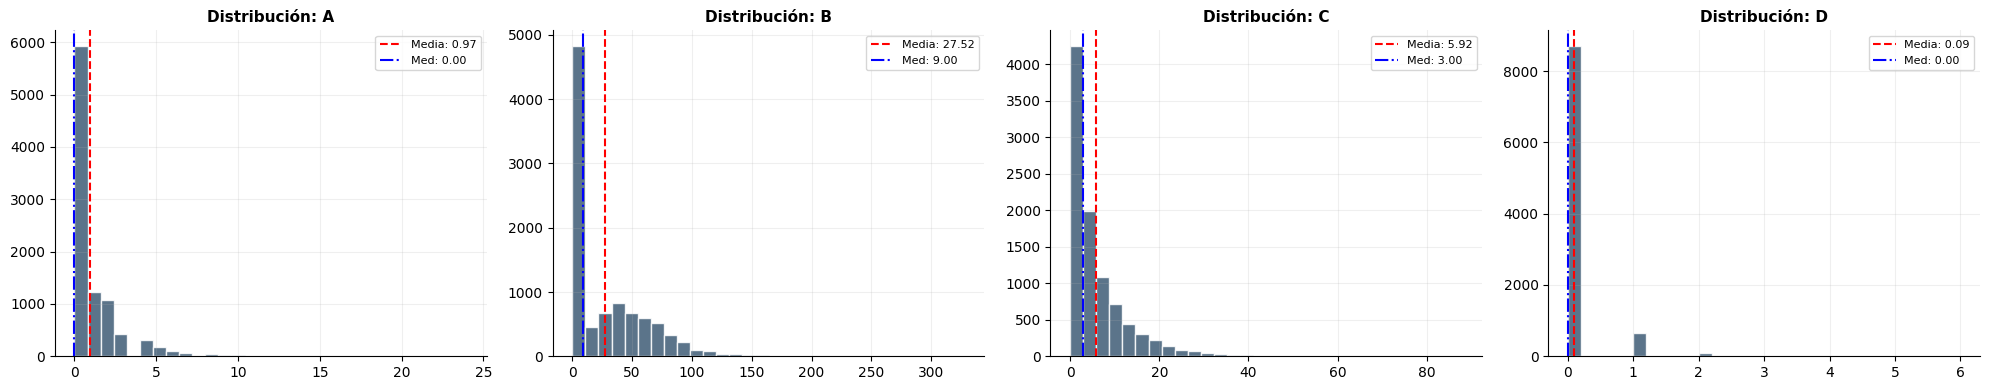

Densidad Discriminativa (Divergencia KL condicionada al Target)


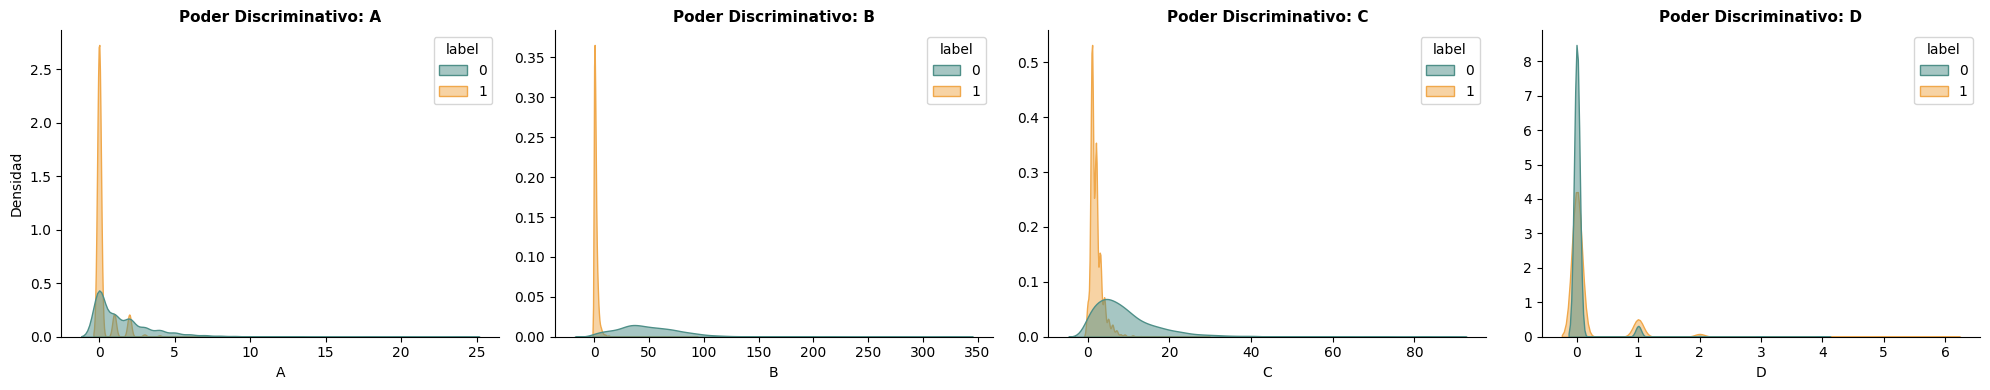

In [14]:
# Importamos las funciones desde nuestro módulo local
from src.plots import plot_distribucion_numericas, plot_densidad_predictiva

# Definimos el espacio de variables base a auditar
COLS_BASE_NUMERICAS = ["A", "B", "C", "D"]

print("------ AUDITORÍA DE VARIABLES BASE NUMÉRICAS ------\n")

print("Topología Univariante")
plot_distribucion_numericas(df, features=COLS_BASE_NUMERICAS, color_principal="#3E5C76")

print("Densidad Discriminativa (Divergencia KL condicionada al Target)")
plot_densidad_predictiva(df, features=COLS_BASE_NUMERICAS, target_col="label")

In [15]:
from src.data_prep import auditar_esparsidad

# Ejecutamos la auditoría sobre las características numéricas
df_esparsidad = auditar_esparsidad(df, features=COLS_BASE_NUMERICAS, umbral_alerta=60.0)

display(df_esparsidad)

,Caracteristica,Ceros_Pct
0,D,92.041010
1,A,62.710073
2,B,21.393087
3,C,5.295423


**1. Auditoría Topológica -->** *Asimetría y Zero-Inflation*

- Las variables **A, B, C y D** presentan una asimetría significativa hacia la derecha y un fenómeno severo de *Zero-Inflation*.

- La tabla de auditoría de esparsidad cuantifica este efecto: la variable **D** está vacía en un 92.04%, y la variable **A** en un 62.71%. Visualmente, esto se comprueba al observar cómo la media (línea roja) es desplazada por los valores atípicos de la cola, alejándose de la mediana (línea azul).

**Decisión:**
Evitar aplicar `StandardScaler` sobre estas distribuciones, ya que desplazaría el valor cero y **destruiría la esparsidad**, eliminando información relevante. En su lugar, es preferible emplear transformaciones robustas a *outliers* (como `RobustScaler` o `log`) y considerar que, ante este tipo de distribuciones altamente sesgadas y esparsas, los modelos basados en árboles suelen ofrecer una ventaja natural.

**2. Poder Discriminativo**

Al condicionar las densidades de probabilidad a la variable objetivo (`label`), se observa:

* **El poder de A, B y C:** Las gráficas muestran una separación clara. La clase 1 (naranja) se concentra casi por completo en el valor cero, mientras que la clase 0 (verde) se distribuye a lo largo de un rango más amplio, generando colas largas. Esto implica una alta ganancia de información.

* **Solapamiento de la variable D:** Las distribuciones de ambas clases en la variable D se superponen prácticamente por completo, lo que indica un bajo poder discriminativo.

**Decisión:**  
Se recomienda la eliminación de la variable **D**. Con un 92% de esparsidad y una capacidad nula para separar clases, su presencia solo añadiría ruido computacional e introduciría inestabilidad en los modelos.

In [16]:
# Extreamos características relevantes de los datos
tabla_resumen = df[COLS_BASE_NUMERICAS].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.99]).T
tabla_resumen = tabla_resumen[['count', 'min', '50%', '75%', '90%', '99%', 'max']]
tabla_resumen.rename(columns={'count': 'N', '50%': 'Mediana'}, inplace=True)
display(tabla_resumen.round(2))

,N,min,Mediana,75%,90%,99%,max
A,9461.0,0.0,0.0,1.0,3.0,8.0,24.0
B,9461.0,0.0,9.0,48.0,75.0,137.0,328.0
C,9461.0,0.0,3.0,8.0,15.0,35.0,88.0
D,9461.0,0.0,0.0,0.0,0.0,2.0,6.0


**3. Fronteras de Acotación**

La extracción de percentiles muestra el impacto de la cola larga de las distribuciones. Si observamos la diferencia entre el percentil 99 y el valor Máximo:

* La variable **B** salta bruscamente de $137.0$ a un máximo de $328.0$.
* La variable **C** salta de $35.0$ a $88.0$.
* La variable **A** salta de $8.0$ a $24.0$.

**Decisión**:  
Se establecen los valores P99 como umbrales para una futuro proceso de *Clipping*. Cualquier valor $x > P99$ será saturado al valor P99.

#### II. Variable base categórica

------ AUDITORÍA DE LA VARIABLE CATEGÓRICA ------


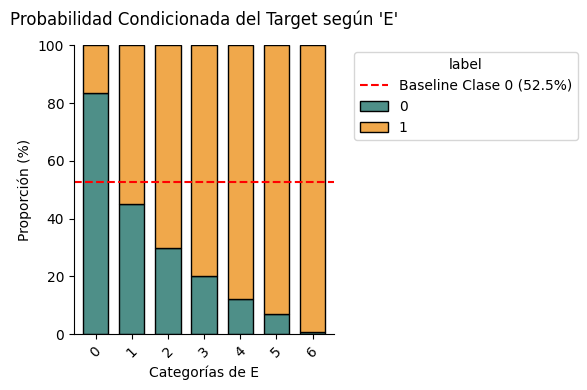

In [17]:
from src.plots import plot_categorica_proporcional

COLS_BASE_CATEGORICAS = "E" 

print("------ AUDITORÍA DE LA VARIABLE CATEGÓRICA ------")
plot_categorica_proporcional(df, cat_col=COLS_BASE_CATEGORICAS, target_col="label")

Existe una **relación monótona estricta** entre la magnitud de la variable `E` y la probabilidad de pertenecer a la clase 1 (naranja) (sin que sea realmente una variable ordinal propia).

* Cuando `E` = 0, la clase 0 domina la distribución (probabilidad > 80%), situándose muy por encima del *baseline* del dataset (52.5%).
* A medida que aumenta el nivel de `E`, la clase 1 incrementa progresivamente su densidad de probabilidad.
* En los valores superiores (`E` = 5 y `E` = 6), la clase 1 representa prácticamente el 100% de los registros.

**Decisión:**  
Debido a la **ordinalidad estricta** detectada, se descarta aplicar **One-Hot Encoding** y se recomienda tratarla como variable ordinal aunque de origen no lo sea.

**Consideración:** Se da visto bueno a las iteraciones con la variable `E` para generar nuevas columnas.

---

Para auditar el espacio de características (Valor_1 $\dots$ Valor_10), se omite el análisis univariante por redundancia topológica y se procede directamente a una auditoría matricial (Heatmap de Pearson) para detectar Fugas de Información y Colinealidad Crítica.

### **1.5. Multicolinealidad**

--- AUDITORÍA DE MULTICOLINEALIDAD ---


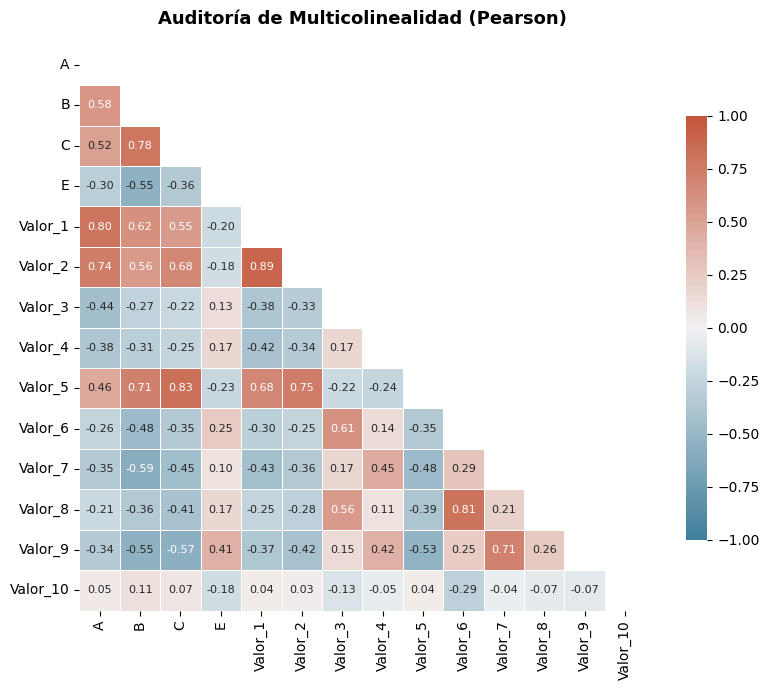

In [18]:
from src.plots import plot_matriz_correlacion

# Definimos el espacio de características, excluyendo 'D' (ya eliminada)
# y asumiendo que quieres auditar A, B, C, E y los 10 Valores
COLS_AUDITORIA = ["A", "B", "C", "E"] + [f"Valor_{i}" for i in range(1, 11)]

print("--- AUDITORÍA DE MULTICOLINEALIDAD ---")
plot_matriz_correlacion(df, features=COLS_AUDITORIA)

**Multicolinealidad Estructural (Pearson)**

Se selecciona el coeficiente de correlación de Pearson ($r$) para auditar la **proporcionalidad lineal** del espacio de características.

Fijando un umbral crítico de colinealidad en $|r| \geq 0.80$:
* **Redundancia entre variables:** `Valor_1` y `Valor_2` presentan una dependencia cuasi-perfecta ($r = 0.89$). Un patrón similar ocurre entre `Valor_8` y `Valor_6` ($r = 0.81$).
* **Solapamiento con variables base:** `Valor_5` se solapa con la variable `C` ($r = 0.83$) y `Valor_1` con `A` ($r = 0.80$).

**Decisión --> Reducción de Dimensionalidad:**
Para garantizar un modelo más simple y optimizar la complejidad espacial en el entrenamiento, se recomienda la purga para las características: **`Valor_1`**, **`Valor_2`**, **`Valor_5`** y **`Valor_8`(o `Valor_6`)**.

### <span style="color:#2F7597">**1.6. Conclusiones de la EDA y Directrices**</span>

#### 1. Topología Univariante: Asimetría y Zero-Inflation
* Las variables continuas base presentan una concentración masiva en $x=0$ y colas largas. Existe un salto considerable entre el percentil 99 (P99) y el valor máximo absoluto.
* **Decisión:** Se descarta la estandarización `StandardScaler`, dependiente de la media, para evitar destruir la esparsidad natural. Se añadirá al *pipeline* una capa de **Clipping en el P99** (durante el particionado de entrenamiento para evitar fugas) seguido de un `RobustScaler`, protegiendo así la estabilidad del descenso de gradiente en el *baseline* lineal.

#### 2. Ganancia de Información y Reducción de Dimensionalidad
* **Purga por Esparsidad:** La variable **`D`** presenta un 92% de valores nulos y nula divergencia distributiva condicionada al *target*. Queda eliminada del espacio de características.
* **Purga por Colinealidad:** La matriz de Pearson muestra que varias variables presentan una redundancia considerable ($|r| \geq 0.80$), consecuencia de las transformaciones aplicadas. Para evitar que la matriz de covarianza $(X^T X)^{-1}$ se vuelva inestable y que las métricas de importancia del modelo (como SHAP) pierdan fiabilidad, se eliminan las características **`Valor_1`**, **`Valor_2`**, **`Valor_5`** y **`Valor_8`**.

#### 3. Topología Ordinal y Monotonicidad
* La probabilidad condicionada muestra una relación monótona estricta entre la magnitud de la variable **`E`** y la probabilidad de pertenencia a la clase minoritaria $P(Y=1 | E)$.
* **Decisión:** Queda prohibido realizar *One-Hot Encoding*.